## Практика 4. Обучение Decision Tree и Random Forest

EDA, препроцессинг и логистическая регрессия перенесены с предыдущих практик. 

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

### Загрузка данных и первичный осмотр

In [21]:
titanic_data = pd.read_csv("Titanic-Dataset.csv",  index_col="PassengerId")

titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [23]:
titanic_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [24]:
titanic_data.dtypes

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
dtype: object

### Выводы по структуре датасета:

Датасет содержит 891 запись и 11 переменных. 

**Целевая переменная - `Survived`.**
- Она отображает выжил определенный пассажир (значение 1) или же нет (значение 0). Среднее значение `0.384` показывает, что выжило только 38.4% пассажиров. 

**В датасете присутствуют, как числовые, так и категориальные переменные.**
- Числовые: `Age`, `Fare`, `SibSp`, `Parch`.
- Категориальные: `Sex`, `Embarked`, `Cabin`, `Ticket`, `Name`. `Pclass` и `Survived` также являются категориальными переменными, но отображены они численно.

**Есть пропущенные значения**
- В колонке `Age` отсутствует 177 значений - 19.86%
- В колонке `Cabin` отсутствует 687 значений - 77.1%
- В колонке `Embarked` отсутствует 2 значения - 0.22%

**Возраст пассажиров сильно варьируется**
- Минимальный возраст - `0.42`, максимальный - `80`. Средний возраст около 29 лет. 


### EDA

**Распределения**

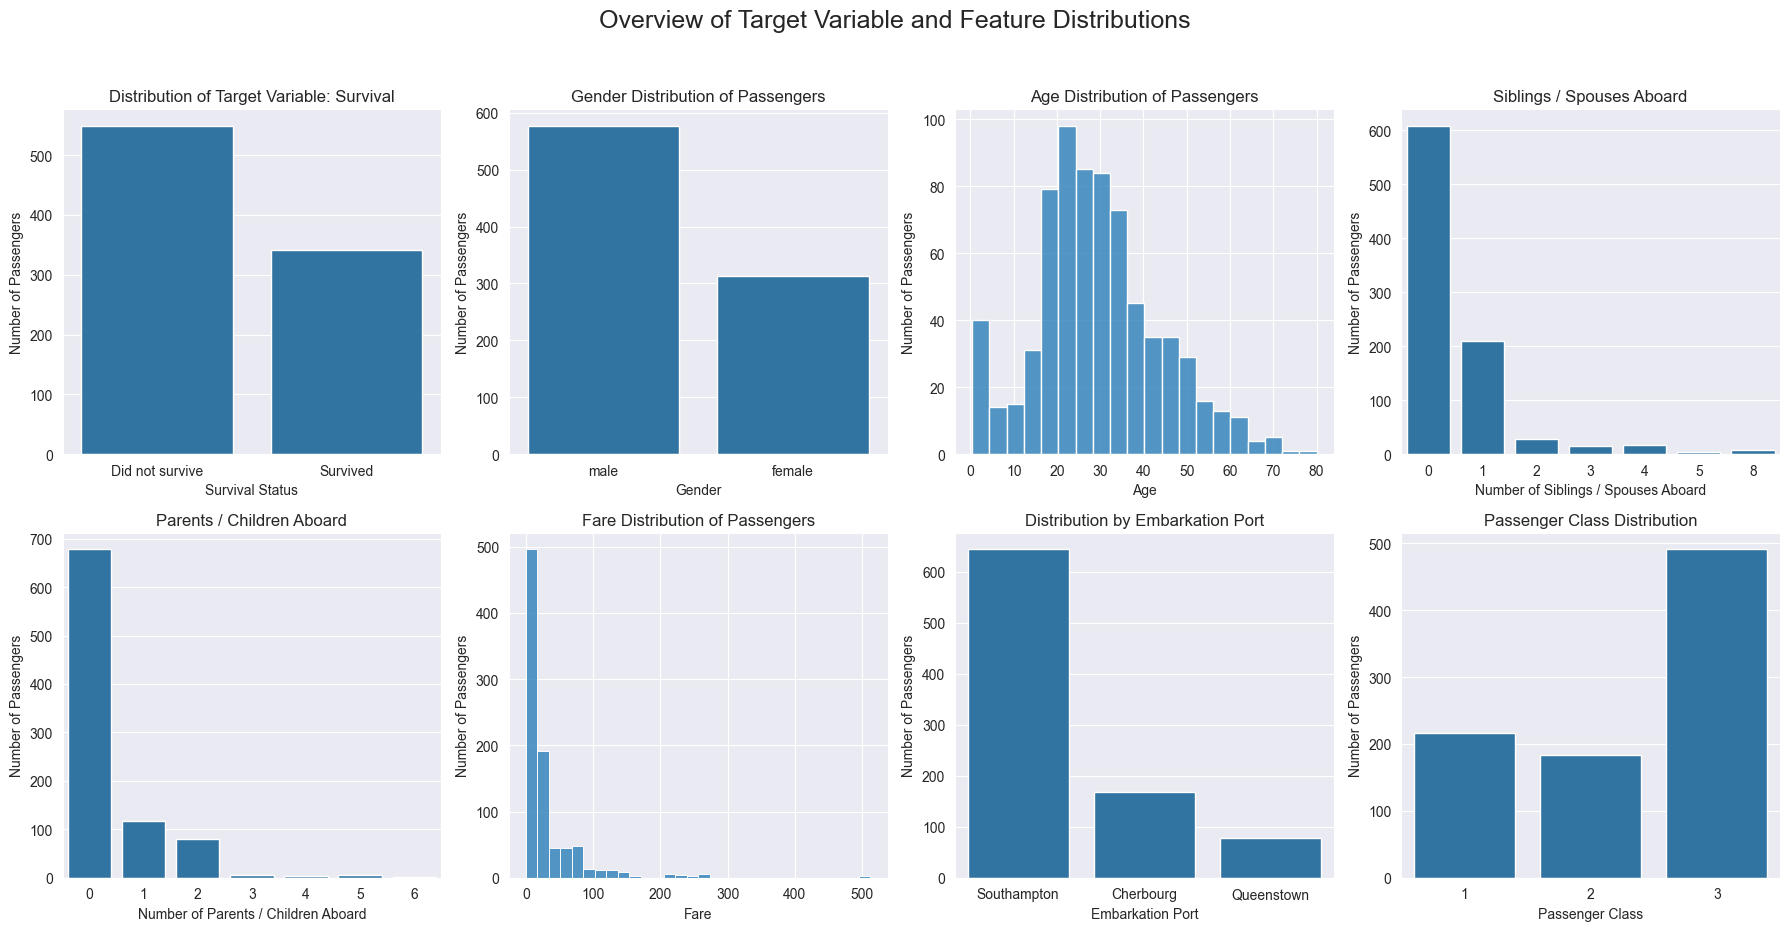

In [25]:
sns.set_style("darkgrid")

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

target_df = titanic_data.copy()

target_df["SurvivedLabel"] = target_df["Survived"].map({
    0: "Did not survive",
    1: "Survived"
})

# Target
sns.countplot(data=target_df, x="SurvivedLabel", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Target Variable: Survival")
axes[0, 0].set_xlabel("Survival Status")
axes[0, 0].set_ylabel("Number of Passengers")

# Gender
sns.countplot(data=titanic_data, x="Sex", ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution of Passengers")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Number of Passengers")

# Age
sns.histplot(data=titanic_data, x="Age", stat="count", ax=axes[0, 2])
axes[0, 2].set_title("Age Distribution of Passengers")
axes[0, 2].set_xlabel("Age")
axes[0, 2].set_ylabel("Number of Passengers")

# SibSp
sns.countplot(data=titanic_data, x="SibSp", ax=axes[0, 3])
axes[0, 3].set_title("Siblings / Spouses Aboard")
axes[0, 3].set_xlabel("Number of Siblings / Spouses Aboard")
axes[0, 3].set_ylabel("Number of Passengers")

#Parch
sns.countplot(data=titanic_data, x="Parch", ax=axes[1, 0])
axes[1, 0].set_title("Parents / Children Aboard")
axes[1, 0].set_xlabel("Number of Parents / Children Aboard")
axes[1, 0].set_ylabel("Number of Passengers")

# Fare
sns.histplot(data=titanic_data, x="Fare", bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Fare Distribution of Passengers")
axes[1, 1].set_xlabel("Fare")
axes[1, 1].set_ylabel("Number of Passengers")

#Embark
embark_df = titanic_data.copy()

embark_df["EmbarkPort"] = embark_df["Embarked"].map({
    "S": "Southampton",
    "C": "Cherbourg",
    "Q": "Queenstown"
})

sns.countplot(data=embark_df, x="EmbarkPort", ax=axes[1, 2])
axes[1, 2].set_title("Distribution by Embarkation Port")
axes[1, 2].set_xlabel("Embarkation Port")
axes[1, 2].set_ylabel("Number of Passengers")

#Pclass
sns.countplot(data=titanic_data, x="Pclass", ax=axes[1, 3])
axes[1, 3].set_title("Passenger Class Distribution")
axes[1, 3].set_xlabel("Passenger Class")
axes[1, 3].set_ylabel("Number of Passengers")

fig.suptitle("Overview of Target Variable and Feature Distributions", fontsize=18, y=1.03)


plt.tight_layout()
plt.show()

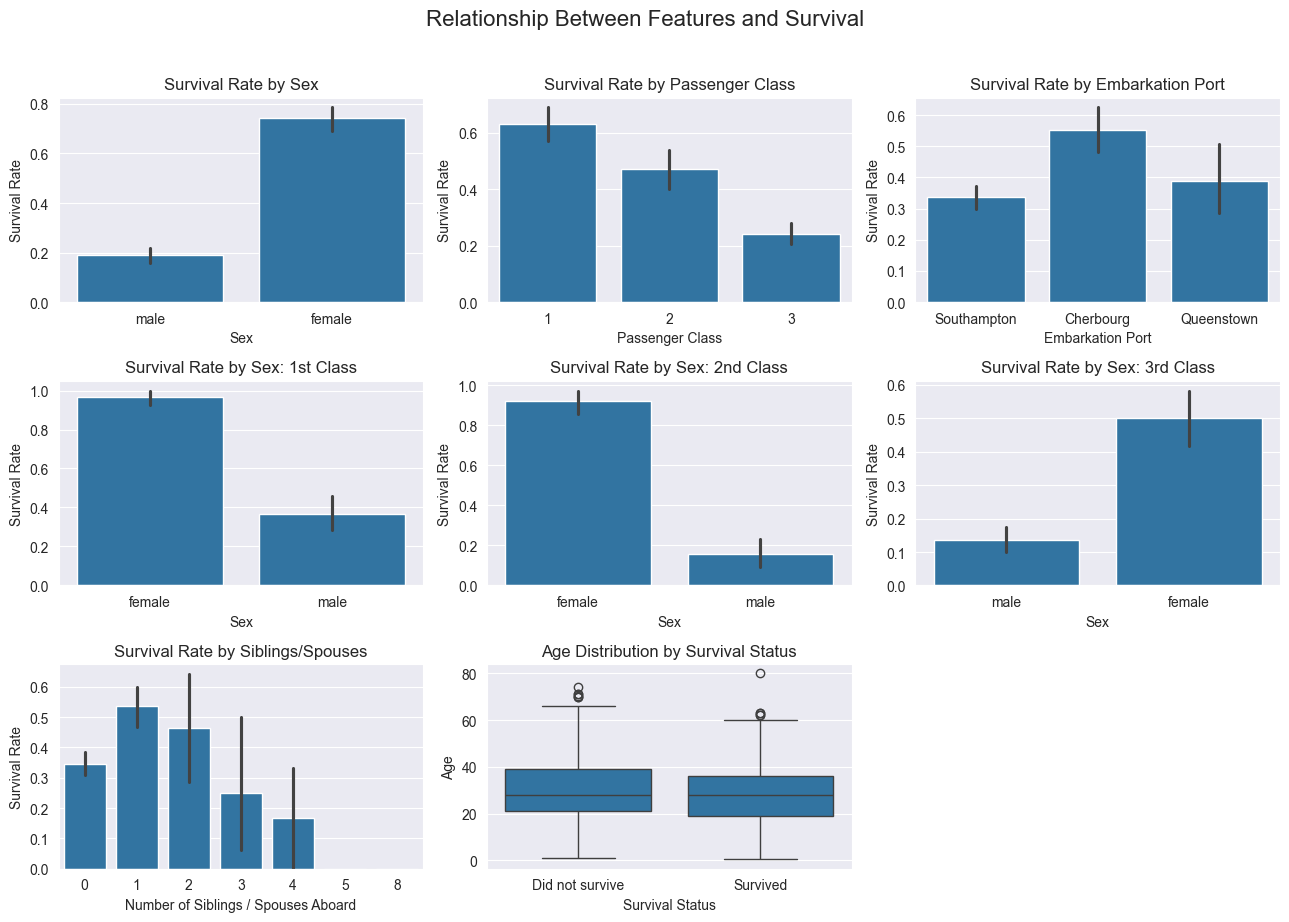

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))

# Sex
sns.barplot(data=titanic_data, x="Sex", y="Survived", ax=axes[0, 0])
axes[0, 0].set_title("Survival Rate by Sex")
axes[0, 0].set_xlabel("Sex")
axes[0, 0].set_ylabel("Survival Rate")


# 2. Pclass
sns.barplot(data=titanic_data, x="Pclass", y="Survived", ax=axes[0, 1])
axes[0, 1].set_title("Survival Rate by Passenger Class")
axes[0, 1].set_xlabel("Passenger Class")
axes[0, 1].set_ylabel("Survival Rate")


# 3. Embark
embarked_df = titanic_data.copy()

embarked_df["EmbarkPort"] = embarked_df["Embarked"].map({
    "S": "Southampton",
    "C": "Cherbourg",
    "Q": "Queenstown"
})

sns.barplot(data=embarked_df, x="EmbarkPort", y="Survived", ax=axes[0, 2])
axes[0, 2].set_title("Survival Rate by Embarkation Port")
axes[0, 2].set_xlabel("Embarkation Port")
axes[0, 2].set_ylabel("Survival Rate")


# Sex pclass 1
class_1 = titanic_data[titanic_data["Pclass"] == 1]

sns.barplot(data=class_1, x="Sex", y="Survived", ax=axes[1, 0])
axes[1, 0].set_title("Survival Rate by Sex: 1st Class")
axes[1, 0].set_xlabel("Sex")
axes[1, 0].set_ylabel("Survival Rate")


# 5. Sex pclass2
class_2 = titanic_data[titanic_data["Pclass"] == 2]

sns.barplot(data=class_2, x="Sex", y="Survived", ax=axes[1, 1])
axes[1, 1].set_title("Survival Rate by Sex: 2nd Class")
axes[1, 1].set_xlabel("Sex")
axes[1, 1].set_ylabel("Survival Rate")


# 6. Sex pclass 3
class_3 = titanic_data[titanic_data["Pclass"] == 3]

sns.barplot(data=class_3, x="Sex", y="Survived", ax=axes[1, 2])
axes[1, 2].set_title("Survival Rate by Sex: 3rd Class")
axes[1, 2].set_xlabel("Sex")
axes[1, 2].set_ylabel("Survival Rate")


# 7. SibSp
sns.barplot(data=titanic_data, x="SibSp", y="Survived", ax=axes[2, 0])
axes[2, 0].set_title("Survival Rate by Siblings/Spouses")
axes[2, 0].set_xlabel("Number of Siblings / Spouses Aboard")
axes[2, 0].set_ylabel("Survival Rate")


# 8. Age Distrib
survival_df = titanic_data.copy()

survival_df["SurvivedLabel"] = survival_df["Survived"].map({
    0: "Did not survive",
    1: "Survived"
})

sns.boxplot(data=survival_df, x="SurvivedLabel", y="Age", ax=axes[2, 1])
axes[2, 1].set_title("Age Distribution by Survival Status")
axes[2, 1].set_xlabel("Survival Status")
axes[2, 1].set_ylabel("Age")


axes[2, 2].axis("off")


fig.suptitle("Relationship Between Features and Survival", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

### **!! Переставила часть с Feature Engineering сюда, чтобы сохранялась более понятная структура ноутбука.**

In [27]:
### FEATURE ENGINEERING

titanic_data["Title"] = titanic_data["Name"].str.extract(r",\s*([^\.]+)\.")
titanic_data["Title"] = titanic_data["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

rare_titles = [
    "Dr", "Rev", "Col", "Major", "Capt",
    "Don", "Lady", "Sir", "the Countess", "Jonkheer"
]

titanic_data["Title"] = titanic_data["Title"].replace(rare_titles, "Rare") ## Visualisations with Titles?

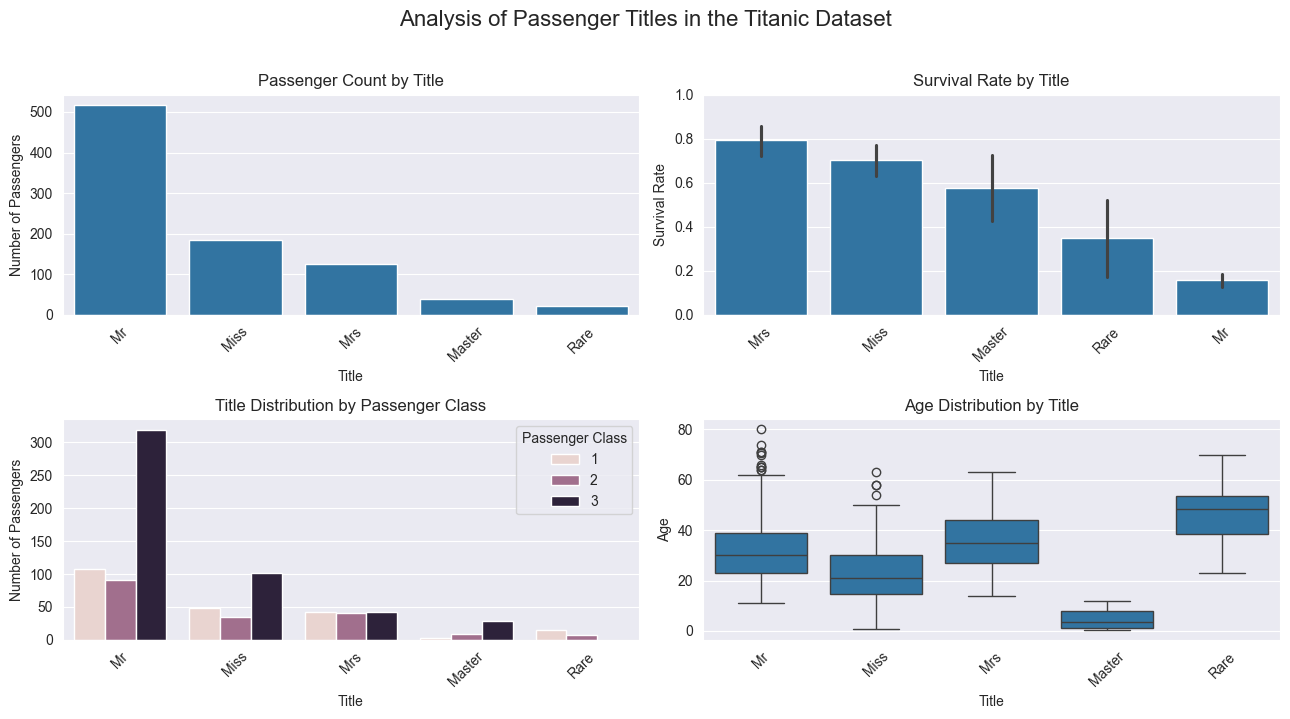

In [28]:
title_df = titanic_data.copy()

title_order = title_df["Title"].value_counts().index

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# count by title
sns.countplot(
    data=title_df,
    x="Title",
    order=title_order,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Passenger Count by Title")
axes[0, 0].set_xlabel("Title")
axes[0, 0].set_ylabel("Number of Passengers")
axes[0, 0].tick_params(axis="x", rotation=45)


# surv rate by title
survival_order = (
    title_df.groupby("Title")["Survived"]
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.barplot(
    data=title_df,
    x="Title",
    y="Survived",
    order=survival_order,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Survival Rate by Title")
axes[0, 1].set_xlabel("Title")
axes[0, 1].set_ylabel("Survival Rate")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=45)


# Pclass distrib
sns.countplot(
    data=title_df,
    x="Title",
    hue="Pclass",
    order=title_order,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Title Distribution by Passenger Class")
axes[1, 0].set_xlabel("Title")
axes[1, 0].set_ylabel("Number of Passengers")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].legend(title="Passenger Class")


# age distrib
sns.boxplot(
    data=title_df,
    x="Title",
    y="Age",
    order=title_order,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Age Distribution by Title")
axes[1, 1].set_xlabel("Title")
axes[1, 1].set_ylabel("Age")
axes[1, 1].tick_params(axis="x", rotation=45)

fig.suptitle("Analysis of Passenger Titles in the Titanic Dataset", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

In [29]:
titanic_data['Title'].value_counts()

percentages = (titanic_data['Title'].value_counts() / len(titanic_data)) * 100

percentages

Title
Mr        58.024691
Miss      20.763187
Mrs       14.141414
Master     4.489338
Rare       2.581369
Name: count, dtype: float64

**Корреляционная матрица**

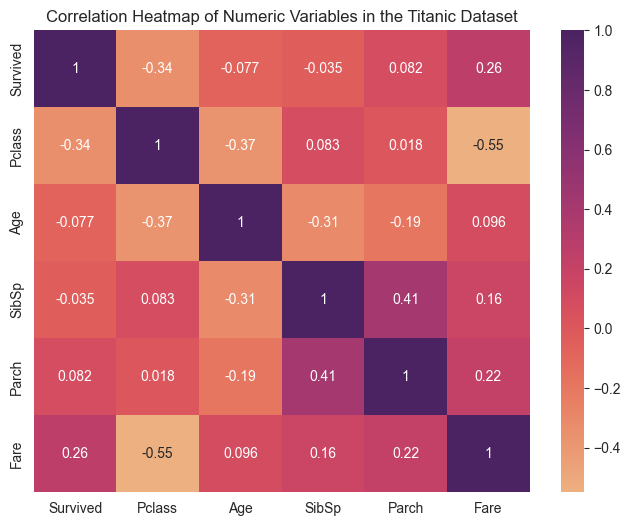

In [30]:
corr_matrix = titanic_data.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='flare')

plt.title("Correlation Heatmap of Numeric Variables in the Titanic Dataset")
plt.show()

In [31]:
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Number of outliers: {outliers.shape[0]}")
    print("-" * 40)

    return outliers


age_outliers = find_outliers_iqr(titanic_data, "Age")
fare_outliers = find_outliers_iqr(titanic_data, "Fare")

Age
Q1: 20.125
Q3: 38.0
IQR: 17.875
Lower bound: -6.6875
Upper bound: 64.8125
Number of outliers: 11
----------------------------------------
Fare
Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower bound: -26.724
Upper bound: 65.6344
Number of outliers: 116
----------------------------------------


**Выводы**

>**Основные выводы по распределениям целевой переменной и признаков:**
 >- `Survival`: Большая часть пассажиров не выжила. Классы несбалансированны.
 >
 >- `Sex`: Большое количество пассажиров были мужчинами. 
 >
 >- `Age`: В среднем, пассажиры были довольно молодыми - в возрасте от (~) 18 до 33 лет. Из интересного, присутствует также достаточно большое количество детей малого возраста и также есть несколько пассажиров пожилого возраста (старше 70 лет). Есть 11 выбросов, все старше 64 лет. 
 >
 >- `SibSp` & `Parch`: Чаще всего пассажиры путешествовали без семьи. 
 >
 >- `Fare`: Ассиметричное распределение, скошенное вправо. В среднем билеты стоили на так много, но есть несколько очень высоких значений. Достаточно большое количество выбросов - 116. 
 >
 >- `Embarked`: Наибольшее количество пассажиров село на борт в Southampton. Это является логичным поскольку это была стартовая точка маршрута. С каждой последующей остановкой количество новых пассажиров уменьшается. 
 >
 >- `Pclass`: Большинство пассажиров ехали в третьем классе, тогда как первый и второй классы представлены меньшим количеством наблюдений.




>**Основные выводы по влиянию признаков на долю выживших:**
>- `Sex`: Пол пассажира сильно связан с вероятностью выживания. Женщины имели значительно более высокую долю выживших, чем мужчины.
>
>- `Pclass`: Пассажирский класс также заметно связан с выживаемостью. Самая высокая доля выживших наблюдается среди пассажиров первого класса, ниже — во втором классе, и самая низкая — в третьем. Показывает влияние социально-экономического статуса.
>
>- `Embarked`: Самая высокая доля выживших наблюдается среди пассажиров, севших на борт в Cherbourg.
>
>- `Sex + Pclass`: При разделении по классам видно, что женщины имели более высокую вероятность выживания во всех пассажирских классах. Особенно высокая доля выживших наблюдается среди женщин первого и второго класса. Среди мужчин, наоборот, доля выживших была низкой, особенно во втором и третьем классах.
>
>- `SibSp`: Пассажиры с 1–2 siblings/spouses aboard имели более высокую долю выживших, чем пассажиры без siblings/spouses или с большим их количеством. Может указывать на то, что наличие небольшой семьи на борту было связано с более высокой вероятностью выживания, тогда как большие семьи могли сталкиваться с большими трудностями при эвакуации.
>
>- `Age`: Распределения возраста среди выживших и не выживших пассажиров в целом похожи, существенной разницы в медианных значениях не наблюдается. Указывает на то, что возраст сам по себе, вероятно не сильно влиял на выживаемость. 




>**Корреляционная матрица:**
>
>В целом, heatmap показывает, что сильных корреляций между переменными нет. 
>
>Есть несколько умеренно или слабо негативных: Pclass x Fare (-0.55), Pclass x Age (-0.37), Survived x Pclass (-0.34). 
>
>Есть одна умеренно позитивная: SibSp x Parch (0.41) - связь между количеством братьев/сестер или супругов и количеством родителей/детей на борту. 



>**Анализ `Title` признака**
>
>Самая высокая выживаемость была у замужних женщин (`Mrs`). После них идут незамужние женщины и девушки (`Miss`), а затем мальчики (`Master`). В целом, сохранялся общий приоритет спасения женщин и детей. Интересно, что мальчики (`Master`) выживали чаще, чем взрослые мужчины (`Mr`), хотя обе группы относятся к мужскому полу. Пассажиры с редкими титулами (`Rare`) имели сравнительно низкую выживаемость. Однако нужно понимать, что их процентное содержание довольно мало. 
>
>По распределению титулов внутри классов видно, что замужние женщины (`Mrs`) были представлены примерно одинаково во всех трех классах. Пассажиры с редкими титулами (`Rare`) встречались только в первом и втором классе - показывает общий социальный статус. 
>
>Незамужние девушки, в среднем, были молодыми - медианное значение около 20 лет. При этом несколько выбросов присутствует - незамужние женщины старше ~50 лет. Rare титулы в основном у людей около 50 лет.
>
>Самый старый пассажир на борту относился к группе `Mr`.


### Предобработка

> **Обработка пропусков**
> 
> В данный момент три колонки содержат в себе пропущенные значения: 
> 
> - `Age` : 19.86%, 
> - `Cabin` : 77.1%, 
> - `Embarked` 0.22%
>
>Имеет смысл удалить колонку `Cabin`, так как много значений пропущены и также потому что логически корректно заполнить пропуски будет сложно: `Cabin` является номинальной категориальной переменной - каюты имели разные номера, находились на разных палубах и различались в зависимости от пассажирского класса. 
>
>Пропущенные значения в `Age`, полагаю, что наиболее корректно заполнить медианными значениями, рассчитанными отдельно для групп по полу и пассажирскому классу. Выбран такой подход, так как средний возраст для разных полов и классов отличается. Медиана используется, так как распределения имеют ассиметрию, а среднее является чувствительным к этому. Также из интереса планирую сравнить показатели модели (LogReg) в зависимости от способа подстановки (пока просто отдельные планы). 
>
>В `Embarked`, два пропущенных значения думаю можно заполнить самым встречающимся значением. Это Southampton. 
>
>В общем целом, также думаю, что, после Feature Engineering'а стоит удалить колонки `Name` и `Ticket`. Переменные также являются номинальными, и не привнесут никакой пользы для последующего prediction'а. 

>**Кодирование категориальных переменных**
>
>Для `Sex`, `Embarked` и `Title`, созданной в последствии Feature Engineering, было использовано One-Hot Encoding, так как они являются номинальными переменными и также низкой кардинальности. 
>
>Для `Pclass` был бы  использован OrdinalEncoder, так как ординальная переменная. Однако в этом датасете признак уже закодирован. 


>**Масштабирование**
>
>Так как колонки `Age` и `Fare` содержат выбросы, особенно колонка `Fare`, где выбросов больше и они значительно выражены, для масштабирования числовых признаков был выбран `RobustScaler`. 

>**Feature Engineering**
>
>В качестве feature engineering, из колонки `Name` был извлечен новый признак `Title`, который отражает социальный титул пассажира и может содержать полезную информацию. 

Кастомный imputer для подстановки по полу и пассажирскому классу:

In [32]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd


class AgeGroupMedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self, age_col="Age", group_cols=["Pclass", "Sex"]):
        self.age_col = age_col
        self.group_cols = group_cols

    def fit(self, X, y=None):
        X = X.copy()

        self.group_medians_ = (
            X.groupby(self.group_cols)[self.age_col]
            .median()
        )

        self.global_median_ = X[self.age_col].median()

        return self

    def transform(self, X):
        X = X.copy()

        missing_age = X[self.age_col].isna()

        for idx in X[missing_age].index:
            group_key = tuple(X.loc[idx, self.group_cols])

            if group_key in self.group_medians_.index:
                X.loc[idx, self.age_col] = self.group_medians_.loc[group_key]
            else:
                X.loc[idx, self.age_col] = self.global_median_

        return X
    

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer,  KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

### FEATURE & TARGET SPLIT

X = titanic_data.drop("Survived", axis=1)
y = titanic_data["Survived"]


X = X.drop(columns=["Name", "Ticket", "Cabin"]) 

X_train, X_valid, y_train, y_valid = train_test_split( 
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

### SCALING & ENCODING & IMPUTING PIPELINE

age_col = ["Age"]
numerical_cols = ["SibSp", "Parch", "Fare"]
categorical_cols = ["Sex", "Embarked", "Title"]


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ('scaler', RobustScaler()) 
])

categorical_transformer = Pipeline(steps =[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) 
])

age_scaler = Pipeline(steps =[
    ('scaler', RobustScaler()) 
])


preprocessor = ColumnTransformer(
    transformers= [
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols),
        ('age_scale', age_scaler, age_col)
    ]
)

### first imputes age, then do num transform, cat transform, and then age scale

### LOGISTIC REGRESSION
model_logreg = Pipeline(steps=[
    ("age_group_imputer", AgeGroupMedianImputer(
        age_col="Age",
        group_cols=["Pclass", "Sex"]
    )),
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

### DECISION TREE CLASSIFIER
model_dt = Pipeline(steps=[
    ("age_group_imputer", AgeGroupMedianImputer(
        age_col="Age",
        group_cols=["Pclass", "Sex"]
    )),
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

### RANDOM FOREST CLASSIFIER

model_rm = Pipeline(steps=[
    ("age_group_imputer", AgeGroupMedianImputer(
        age_col="Age",
        group_cols=["Pclass", "Sex"]
    )),
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [35]:
### JUST TO SEE HOW THE RESULT LOOKS

X_age_imputed = model_logreg.named_steps["age_group_imputer"].fit_transform(X_train)
X_processed = model_logreg.named_steps["preprocessor"].fit_transform(X_age_imputed)

feature_names = model_logreg.named_steps["preprocessor"].get_feature_names_out()

X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names,
    index=X_age_imputed.index
)

X_processed_df.head()

,num__SibSp,num__Parch,num__Fare,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,cat__Title_Master,cat__Title_Miss,cat__Title_Mr,cat__Title_Mrs,cat__Title_Rare,age_scale__Age
PassengerId,,,,,,,,,,,,,,
693,0.0,0.0,1.819652,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.064516
482,0.0,0.0,-0.625609,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.193548
528,0.0,0.0,8.973477,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.838710
856,0.0,1.0,-0.220921,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.580645
802,1.0,1.0,0.510548,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.258065


In [36]:
X_processed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 693 to 508
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   num__SibSp         712 non-null    float64
 1   num__Parch         712 non-null    float64
 2   num__Fare          712 non-null    float64
 3   cat__Sex_female    712 non-null    float64
 4   cat__Sex_male      712 non-null    float64
 5   cat__Embarked_C    712 non-null    float64
 6   cat__Embarked_Q    712 non-null    float64
 7   cat__Embarked_S    712 non-null    float64
 8   cat__Title_Master  712 non-null    float64
 9   cat__Title_Miss    712 non-null    float64
 10  cat__Title_Mr      712 non-null    float64
 11  cat__Title_Mrs     712 non-null    float64
 12  cat__Title_Rare    712 non-null    float64
 13  age_scale__Age     712 non-null    float64
dtypes: float64(14)
memory usage: 99.6 KB


In [37]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score


def evaluate_model(model, model_name, X_train, y_train, X_valid, y_valid):

    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")

    ## CV on train data

    # Accuracy CV
    cv_acc = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    print("\nCV Accuracy scores:", cv_acc)
    print("Mean CV Accuracy:", cv_acc.mean())

    # F1 CV
    cv_f1 = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    print("\nCV F1 scores:", cv_f1)
    print("Mean CV F1:", cv_f1.mean())

    # train
    model.fit(X_train, y_train)

    preds = model.predict(X_valid)

    # Validation metrics
    print("\nValidation Accuracy:", accuracy_score(y_valid, preds))
    print("Validation F1:", f1_score(y_valid, preds))

    print("\nClassification Report:")
    print(classification_report(y_valid, preds))

    print("Confusion Matrix:")
    print(confusion_matrix(y_valid, preds))

    return {
        "model_name": model_name,
        "cv_f1_mean": cv_f1.mean(),
        "cv_acc_mean": cv_acc.mean(),
        "valid_accuracy": accuracy_score(y_valid, preds),
        "valid_f1": f1_score(y_valid, preds),
        "preds": preds,
        "model": model
    }

In [38]:
results_logreg = evaluate_model(model_logreg, "Logistic Regression", X_train, y_train, X_valid, y_valid)
results_dt = evaluate_model(model_dt, "Decision Tree", X_train, y_train, X_valid, y_valid)
results_rm = evaluate_model(model_rm, "Random Forest", X_train, y_train, X_valid, y_valid)

summary_df = pd.DataFrame([
    results_logreg,
    results_dt,
    results_rm
])[[
    "model_name",
    "cv_f1_mean",
    "cv_acc_mean",
    "valid_accuracy",
    "valid_f1"
]]

display(summary_df)



Logistic Regression

CV Accuracy scores: [0.78321678 0.83216783 0.83802817 0.83098592 0.82394366]
Mean CV Accuracy: 0.8216684723726978

CV F1 scores: [0.71559633 0.76470588 0.78899083 0.76923077 0.76190476]
Mean CV F1: 0.7600857138903551

Validation Accuracy: 0.8435754189944135
Validation F1: 0.7878787878787878

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       110
           1       0.83      0.75      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179

Confusion Matrix:
[[99 11]
 [17 52]]

Decision Tree

CV Accuracy scores: [0.68531469 0.71328671 0.75352113 0.74647887 0.71830986]
Mean CV Accuracy: 0.7233822515512657

CV F1 scores: [0.55445545 0.63063063 0.69026549 0.68421053 0.65517241]
Mean CV F1: 0.6429469006019483

Validation Accuracy: 0.7932960893854749
Validation F1: 0.7131782

,model_name,cv_f1_mean,cv_acc_mean,valid_accuracy,valid_f1
0,Logistic Regression,0.760086,0.821668,0.843575,0.787879
1,Decision Tree,0.642947,0.723382,0.793296,0.713178
2,Random Forest,0.720723,0.786654,0.815642,0.748092


### **Сравнение качества Logistic Regression, Decision Tree и Random Forest**

Для сравнения моделей использовались две основные метрики: **Accuracy** и **F1-score**. Accuracy показывает общую долю правильных предсказаний, а F1-score использовался, чтобы поддерживать результаты Accuracy, так как классы не сбалансированы. 

Лучший результат показала модель логистической регрессии. Она получила самый высокий средний результат на кросс-валидации: `CV Accuracy = 0.82` и `CV F1 = 0.76`. На validation dataset модель также показала лучшие значения: `Accuracy = 0.84` и `F1 = 0.79`. 

Дерево решений показало худшие результаты среди трёх моделей. Средний `CV F1` составил только `0.64`, а validation F1 — `0.71`. По confusion matrix также видно, что дерево решений допустило больше ошибок: 14 false positives и 23 false negatives. 

Случайный лес показал результат лучше, чем дерево решений, но хуже, чем логистическая регрессия. Его validation accuracy составила `0.81`, а validation F1 — `0.75`. Достаточно логично, так как Random Forest обычно должен быть стабильнее одиночного дерева за счёт ансамбля. 

По confusion matrix также видно, что логистическая регрессия лучше всего справляется с предсказанием выживших пассажиров: она правильно определила 52 из 69 выживших. Дерева решений этот показатель ниже — 46 из 69, у Random Forest — 49 из 69. При этом логистическая регрессия также допустила меньше false positives, чем остальные модели.

Таким образом, по совокупности метрик лучшей моделью является **Logistic Regression**. 

Нужно отметить, что все модели представленные в данном анализе сравниваются в их стандартной конфигурации. Вполне возможно, что после выбора и настройки гиперпараметров результат изменится. 


TODO:

comparison with other types of imputation